# Evolutionary Computation Project

## Efficiency-Aware Metaheuristic Optimization for Renewable Energy Forecasting

This notebook is a cleaned and Colab-ready implementation for the Evolutionary Computation project. It compares three optimization algorithms:

1. Genetic Algorithm (GA)
2. Particle Swarm Optimization (PSO)
3. Cuckoo Catfish Optimizer (CCO)

The notebook covers two required experimental parts:

- The 23 standard mathematical benchmark functions.
- A real-world renewable energy forecasting problem using `MES_0126.csv`.

The real-world objective is to optimize LSTM hyperparameters for monthly green energy production forecasting. The selected forecasting tasks are Germany, Spain, and Denmark for wind and solar production.

The code is designed for Google Colab, but it can also run locally if the CSV file is in the same folder as this notebook.

## Methodological improvements included

- Removed emojis from markdown, print messages, and plot titles.
- Converted the project to a clean Python notebook suitable for Google Colab.
- Added all three required algorithms: GA, PSO, and CCO.
- Added the 23 mathematical benchmark functions required by the project specification.
- Added a real-world renewable energy forecasting objective using the uploaded monthly electricity dataset.
- Avoided test leakage by using train, validation, and test splits.
- Used validation RMSE as the optimization fitness and reserved test RMSE for final reporting.
- Added reproducibility through controlled random seeds.
- Added fitness caching to reduce repeated LSTM training cost.
- Added early stopping during LSTM training.
- Added statistical evaluation using Friedman and Wilcoxon signed-rank tests.
- Added export of result tables and plots for the report and presentation.

## Cell 1: Install dependencies

Run this cell first in Google Colab. PyTorch is usually preinstalled in Colab, so the notebook only installs missing scientific packages when needed.

In [1]:
import sys
import subprocess
import importlib.util

required_packages = ["numpy", "pandas", "matplotlib", "sklearn", "scipy", "torch"]
missing = []
for pkg in required_packages:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    package_map = {"sklearn": "scikit-learn"}
    install_names = [package_map.get(pkg, pkg) for pkg in missing]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + install_names)

print("Dependency check completed.")

Dependency check completed.


## Cell 2: Imports, configuration, and reproducibility

Use `RUN_PROFILE` to control runtime:

- `debug`: fast smoke test.
- `balanced`: recommended for a complete project run in Colab.
- `conference`: longer run for stronger and more stable results.

In [2]:
from pathlib import Path
import os
import math
import time
import random
import shutil
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

warnings.filterwarnings("ignore")

SEED = 42

# Use "paper" for stronger renewable-energy results.
# Use "conference" only if you have enough Colab GPU time.
RUN_PROFILE = "paper"

# Set this to True later when you want to run all 23 benchmark functions.
# Keep it False while improving the renewable-energy experiment.
RUN_BENCHMARKS = True
RUN_RENEWABLE_EXPERIMENTS = True

PROFILES = {
    "debug": {
        "benchmark_runs": 1,
        "benchmark_functions": [1, 5, 9, 10, 16],
        "benchmark_pop": 12,
        "benchmark_iter": 20,

        "energy_seed_runs": 1,
        "energy_tasks": [("Germany", "Wind")],
        "energy_agents": 4,
        "energy_iter": 3,
        "fitness_epochs": 5,
        "final_epochs": 15,
    },

    "balanced": {
        "benchmark_runs": 5,
        "benchmark_functions": list(range(1, 24)),
        "benchmark_pop": 25,
        "benchmark_iter": 80,

        "energy_seed_runs": 1,
        "energy_tasks": [
            ("Germany", "Wind"), ("Germany", "Solar"),
            ("Spain", "Wind"), ("Spain", "Solar"),
            ("Denmark", "Wind"), ("Denmark", "Solar"),
        ],
        "energy_agents": 8,
        "energy_iter": 8,
        "fitness_epochs": 15,
        "final_epochs": 60,
    },

    "paper": {
        "benchmark_runs": 10,
        "benchmark_functions": list(range(1, 24)),
        "benchmark_pop": 40,
        "benchmark_iter": 200,

        "energy_seed_runs": 3,
        "energy_tasks": [
            ("Germany", "Wind"), ("Germany", "Solar"),
            ("Spain", "Wind"), ("Spain", "Solar"),
            ("Denmark", "Wind"), ("Denmark", "Solar"),
        ],
        "energy_agents": 12,
        "energy_iter": 15,
        "fitness_epochs": 30,
        "final_epochs": 180,
    },

    "conference": {
        "benchmark_runs": 20,
        "benchmark_functions": list(range(1, 24)),
        "benchmark_pop": 50,
        "benchmark_iter": 300,

        "energy_seed_runs": 5,
        "energy_tasks": [
            ("Germany", "Wind"), ("Germany", "Solar"),
            ("Spain", "Wind"), ("Spain", "Solar"),
            ("Denmark", "Wind"), ("Denmark", "Solar"),
        ],
        "energy_agents": 16,
        "energy_iter": 25,
        "fitness_epochs": 40,
        "final_epochs": 220,
    },
}

CFG = PROFILES[RUN_PROFILE]

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_global_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Run profile: {RUN_PROFILE}")
print(f"Device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. In Colab, enable it from Runtime > Change runtime type > GPU.")

Run profile: paper
Device: cpu
GPU not detected. In Colab, enable it from Runtime > Change runtime type > GPU.


## Cell 3: Load the renewable energy dataset

Upload `MES_0126.csv` when Colab asks for it, or place it in the same folder as this notebook.

In [3]:
from pathlib import Path
import pandas as pd

try:
    from google.colab import files

    print("Please upload your dataset file: MES_0126.csv")
    uploaded = files.upload()

    if len(uploaded) == 0:
        raise FileNotFoundError("No file was uploaded.")

    uploaded_filename = list(uploaded.keys())[0]
    DATA_PATH = Path(uploaded_filename)

    print(f"Uploaded file: {uploaded_filename}")

except Exception as exc:
    raise FileNotFoundError(
        "Dataset upload failed. Please upload MES_0126.csv manually."
    ) from exc


df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded file: {DATA_PATH}")
print(f"Shape: {df_raw.shape}")
print("Columns:", list(df_raw.columns))

display(df_raw.head())

Please upload your dataset file: MES_0126.csv


Saving MES_0126.csv to MES_0126.csv
Uploaded file: MES_0126.csv
Loaded file: MES_0126.csv
Shape: (158993, 6)
Columns: ['Country', 'Time', 'Balance', 'Product', 'Value', 'Unit']


,Country,Time,Balance,Product,Value,Unit
0,Australia,26-Jan,Net Electricity Production,Electricity,24289.2124,GWh
1,Australia,26-Jan,Net Electricity Production,Hydro,943.0563,GWh
2,Australia,26-Jan,Net Electricity Production,Total Combustible Fuels,13071.0551,GWh
3,Australia,26-Jan,Net Electricity Production,"Coal, Peat and Manufactured Gases",9366.8997,GWh
4,Australia,26-Jan,Net Electricity Production,Oil and Petroleum Products,315.5568,GWh


## Cell 4: Dataset validation and exploratory summary

This cell verifies that the required columns exist and prints the available renewable energy series.

In [4]:
required_columns = {"Country", "Time", "Balance", "Product", "Value", "Unit"}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Dataset summary")
print("Rows:", len(df_raw))
print("Countries:", df_raw["Country"].nunique())
print("Products:", df_raw["Product"].nunique())
print("Balances:", df_raw["Balance"].nunique())
print("Unit values:", df_raw["Unit"].unique())

renewable_mask = (
    df_raw["Balance"].eq("Net Electricity Production") &
    df_raw["Product"].isin(["Wind", "Solar"])
)
series_counts = (
    df_raw.loc[renewable_mask]
    .groupby(["Country", "Product"])
    .size()
    .reset_index(name="Records")
    .sort_values(["Country", "Product"])
)
display(series_counts.head(20))

Dataset summary
Rows: 158993
Countries: 53
Products: 16
Balances: 7
Unit values: ['GWh']


,Country,Product,Records
0,Argentina,Solar,133
1,Argentina,Wind,133
2,Australia,Solar,193
3,Australia,Wind,193
4,Austria,Solar,193
5,Austria,Wind,193
6,Belgium,Solar,193
7,Belgium,Wind,193
8,Brazil,Solar,133
9,Brazil,Wind,133


## Cell 5: Benchmark functions 1 to 23

These functions follow the same benchmark family used by the uploaded MATLAB files: unimodal, multimodal, and fixed-dimensional multimodal functions.

In [5]:
def benchmark_bounds(function_index):
    dim = 50
    bounds = {
        1: (-100, 100, dim),
        2: (-10, 10, dim),
        3: (-100, 100, dim),
        4: (-100, 100, dim),
        5: (-30, 30, dim),
        6: (-100, 100, dim),
        7: (-1.28, 1.28, dim),
        8: (-500, 500, dim),
        9: (-5.12, 5.12, dim),
        10: (-32, 32, dim),
        11: (-600, 600, dim),
        12: (-50, 50, dim),
        13: (-50, 50, dim),
        14: (-65.536, 65.536, 2),
        15: (-5, 5, 4),
        16: (-5, 5, 2),
        17: (np.array([-5, 0]), np.array([10, 15]), 2),
        18: (-2, 2, 2),
        19: (0, 1, 3),
        20: (0, 1, 6),
        21: (0, 10, 4),
        22: (0, 10, 4),
        23: (0, 10, 4),
    }
    low, high, dim = bounds[function_index]
    low = np.full(dim, low, dtype=float) if np.isscalar(low) else low.astype(float)
    high = np.full(dim, high, dtype=float) if np.isscalar(high) else high.astype(float)
    return low, high, dim


BENCHMARK_NAMES = {
    1: "Sphere",
    2: "Schwefel 2.22",
    3: "Schwefel 1.2",
    4: "Schwefel 2.21",
    5: "Rosenbrock",
    6: "Step",
    7: "Quartic",
    8: "Schwefel",
    9: "Rastrigin",
    10: "Ackley",
    11: "Griewank",
    12: "Penalized 1",
    13: "Penalized 2",
    14: "Foxholes",
    15: "Kowalik",
    16: "Six-Hump Camel",
    17: "Branin",
    18: "Goldstein-Price",
    19: "Hartman 3",
    20: "Hartman 6",
    21: "Shekel 5",
    22: "Shekel 7",
    23: "Shekel 10",
}


def penalty_u(x, a=10, k=100, m=4):
    x = np.asarray(x)
    return np.sum(k * ((x - a) ** m) * (x > a) + k * ((-x - a) ** m) * (x < -a))


def benchmark_function(x, function_index):
    x = np.asarray(x, dtype=float)
    dim = len(x)

    if function_index == 1:
        return np.sum(x ** 2)
    if function_index == 2:
        return np.sum(np.abs(x)) + np.prod(np.abs(x))
    if function_index == 3:
        return sum(np.sum(x[:i + 1]) ** 2 for i in range(dim))
    if function_index == 4:
        return np.max(np.abs(x))
    if function_index == 5:
        return np.sum(100 * (x[1:] - x[:-1] ** 2) ** 2 + (x[:-1] - 1) ** 2)
    if function_index == 6:
        return np.sum(np.floor(x + 0.5) ** 2)
    if function_index == 7:
        return np.sum(np.arange(1, dim + 1) * (x ** 4))
    if function_index == 8:
        return np.sum(-x * np.sin(np.sqrt(np.abs(x))))
    if function_index == 9:
        return np.sum(x ** 2 - 10 * np.cos(2 * np.pi * x)) + 10 * dim
    if function_index == 10:
        return -20 * np.exp(-0.2 * np.sqrt(np.sum(x ** 2) / dim)) - np.exp(np.sum(np.cos(2 * np.pi * x)) / dim) + 20 + np.e
    if function_index == 11:
        return np.sum(x ** 2) / 4000 - np.prod(np.cos(x / np.sqrt(np.arange(1, dim + 1)))) + 1
    if function_index == 12:
        y = 1 + (x + 1) / 4
        return (np.pi / dim) * (10 * np.sin(np.pi * y[0]) ** 2 + np.sum((y[:-1] - 1) ** 2 * (1 + 10 * np.sin(np.pi * y[1:]) ** 2)) + (y[-1] - 1) ** 2) + penalty_u(x)
    if function_index == 13:
        return 0.1 * (np.sin(3 * np.pi * x[0]) ** 2 + np.sum((x[:-1] - 1) ** 2 * (1 + np.sin(3 * np.pi * x[1:]) ** 2)) + (x[-1] - 1) ** 2 * (1 + np.sin(2 * np.pi * x[-1]) ** 2)) + penalty_u(x)
    if function_index == 14:
        a = np.array([
            [-32, -16, 0, 16, 32, -32, -16, 0, 16, 32, -32, -16, 0, 16, 32, -32, -16, 0, 16, 32, -32, -16, 0, 16, 32],
            [-32, -32, -32, -32, -32, -16, -16, -16, -16, -16, 0, 0, 0, 0, 0, 16, 16, 16, 16, 16, 32, 32, 32, 32, 32],
        ], dtype=float)
        b = np.sum((x.reshape(2, 1) - a) ** 6, axis=0)
        return (1 / 500 + np.sum(1 / (np.arange(1, 26) + b))) ** -1
    if function_index == 15:
        a = np.array([0.1957, 0.1947, 0.1735, 0.16, 0.0844, 0.0627, 0.0456, 0.0342, 0.0323, 0.0235, 0.0246])
        b = 1 / np.array([0.25, 0.5, 1, 2, 4, 6, 8, 10, 12, 14, 16])
        return np.sum((a - ((x[0] * (b ** 2 + x[1] * b)) / (b ** 2 + x[2] * b + x[3]))) ** 2)
    if function_index == 16:
        return 4 * x[0] ** 2 - 2.1 * x[0] ** 4 + (x[0] ** 6) / 3 + x[0] * x[1] - 4 * x[1] ** 2 + 4 * x[1] ** 4
    if function_index == 17:
        return (x[1] - (5.1 / (4 * np.pi ** 2)) * x[0] ** 2 + (5 / np.pi) * x[0] - 6) ** 2 + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x[0]) + 10
    if function_index == 18:
        return (1 + (x[0] + x[1] + 1) ** 2 * (19 - 14 * x[0] + 3 * x[0] ** 2 - 14 * x[1] + 6 * x[0] * x[1] + 3 * x[1] ** 2)) * (30 + (2 * x[0] - 3 * x[1]) ** 2 * (18 - 32 * x[0] + 12 * x[0] ** 2 + 48 * x[1] - 36 * x[0] * x[1] + 27 * x[1] ** 2))
    if function_index == 19:
        a = np.array([[3, 10, 30], [0.1, 10, 35], [3, 10, 30], [0.1, 10, 35]], dtype=float)
        c = np.array([1, 1.2, 3, 3.2], dtype=float)
        p = np.array([[0.3689, 0.117, 0.2673], [0.4699, 0.4387, 0.747], [0.1091, 0.8732, 0.5547], [0.03815, 0.5743, 0.8828]], dtype=float)
        return -np.sum(c * np.exp(-np.sum(a * ((x - p) ** 2), axis=1)))
    if function_index == 20:
        a = np.array([[10, 3, 17, 3.5, 1.7, 8], [0.05, 10, 17, 0.1, 8, 14], [3, 3.5, 1.7, 10, 17, 8], [17, 8, 0.05, 10, 0.1, 14]], dtype=float)
        c = np.array([1, 1.2, 3, 3.2], dtype=float)
        p = np.array([[0.1312, 0.1696, 0.5569, 0.0124, 0.8283, 0.5886], [0.2329, 0.4135, 0.8307, 0.3736, 0.1004, 0.9991], [0.2348, 0.1415, 0.3522, 0.2888, 0.3047, 0.6650], [0.4047, 0.8828, 0.8732, 0.5743, 0.1091, 0.0381]], dtype=float)
        return -np.sum(c * np.exp(-np.sum(a * ((x - p) ** 2), axis=1)))
    if function_index in [21, 22, 23]:
        m = {21: 5, 22: 7, 23: 10}[function_index]
        a = np.array([[4, 4, 4, 4], [1, 1, 1, 1], [8, 8, 8, 8], [6, 6, 6, 6], [3, 7, 3, 7], [2, 9, 2, 9], [5, 5, 3, 3], [8, 1, 8, 1], [6, 2, 6, 2], [7, 3.6, 7, 3.6]], dtype=float)
        c = np.array([0.1, 0.2, 0.2, 0.4, 0.4, 0.6, 0.3, 0.7, 0.5, 0.5], dtype=float)
        return -np.sum([1 / (np.sum((x - a[i]) ** 2) + c[i]) for i in range(m)])
    raise ValueError(f"Unknown benchmark function: {function_index}")

print("Benchmark functions loaded:", len(BENCHMARK_NAMES))

Benchmark functions loaded: 23


## Cell 6: Generic optimizer result class and helper functions

In [6]:
@dataclass
class OptimizerResult:
    best_position: np.ndarray
    best_fitness: float
    history: list
    runtime_seconds: float


def apply_bounds(x, low, high, rng=None):
    x = np.asarray(x, dtype=float).copy()
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    if rng is not None and rng.random() < 0.5:
        mask = (x < low) | (x > high)
        if np.any(mask):
            x[mask] = low[mask] + rng.random(np.sum(mask)) * (high[mask] - low[mask])
        return x
    return np.clip(x, low, high)


def levy_flight(dim, rng, beta=1.5, scale=0.05):
    sigma_u = (
        math.gamma(1 + beta) * math.sin(math.pi * beta / 2) /
        (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = rng.normal(0, sigma_u, dim)
    v = rng.normal(0, 1, dim)
    return scale * u / (np.abs(v) ** (1 / beta) + 1e-12)

## Cell 7: Genetic Algorithm

In [7]:
def genetic_algorithm(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                      crossover_rate=0.85, mutation_rate=0.15, mutation_scale=0.10,
                      verbose=False):
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])
    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    history = [best_fit]

    def tournament_select():
        k = min(3, pop_size)
        idx = rng.choice(pop_size, size=k, replace=False)
        return pop[idx[np.argmin(fit[idx])]].copy()

    for it in range(1, n_iter + 1):
        new_pop = [best_pos.copy()]
        while len(new_pop) < pop_size:
            p1 = tournament_select()
            p2 = tournament_select()
            if rng.random() < crossover_rate:
                alpha = rng.random(dim)
                c1 = alpha * p1 + (1 - alpha) * p2
                c2 = alpha * p2 + (1 - alpha) * p1
            else:
                c1, c2 = p1.copy(), p2.copy()

            for child in [c1, c2]:
                mutation_mask = rng.random(dim) < mutation_rate
                noise = rng.normal(0, mutation_scale, dim) * (high - low)
                child = child + mutation_mask * noise
                child = apply_bounds(child, low, high, rng)
                new_pop.append(child)
                if len(new_pop) >= pop_size:
                    break

        pop = np.array(new_pop)
        fit = np.array([objective(ind) for ind in pop])
        current_idx = np.argmin(fit)
        if fit[current_idx] < best_fit:
            best_fit = float(fit[current_idx])
            best_pos = pop[current_idx].copy()
        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"GA iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)

## Cell 8: Particle Swarm Optimization

In [8]:
def particle_swarm_optimization(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                                w_start=0.9, w_end=0.4, c1=1.6, c2=1.6,
                                verbose=False):
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    positions = low + rng.random((pop_size, dim)) * (high - low)
    vmax = 0.20 * (high - low)
    velocities = rng.uniform(-vmax, vmax, size=(pop_size, dim))

    pbest_pos = positions.copy()
    pbest_fit = np.array([objective(ind) for ind in positions])
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = float(pbest_fit[gbest_idx])
    history = [gbest_fit]

    for it in range(1, n_iter + 1):
        w = w_start - (w_start - w_end) * (it / max(1, n_iter))
        r1 = rng.random((pop_size, dim))
        r2 = rng.random((pop_size, dim))
        velocities = w * velocities + c1 * r1 * (pbest_pos - positions) + c2 * r2 * (gbest_pos - positions)
        velocities = np.clip(velocities, -vmax, vmax)
        positions = positions + velocities
        positions = np.array([apply_bounds(pos, low, high, rng) for pos in positions])

        fit = np.array([objective(ind) for ind in positions])
        improved = fit < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fit[improved]
        current_idx = np.argmin(pbest_fit)
        if pbest_fit[current_idx] < gbest_fit:
            gbest_fit = float(pbest_fit[current_idx])
            gbest_pos = pbest_pos[current_idx].copy()
        history.append(gbest_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"PSO iteration {it}/{n_iter}: best={gbest_fit:.6g}")

    return OptimizerResult(gbest_pos, gbest_fit, history, time.time() - start)

## Cell 9: Cuckoo Catfish Optimizer

This is a Python implementation adapted from the uploaded MATLAB CCO logic. It keeps the main CCO ideas: population search, best and worst individual guidance, adaptive exploration to exploitation transition, Levy-flight perturbation, stagnation reset, and boundary control.

In [9]:
def cuckoo_catfish_optimizer(objective, low, high, pop_size=25, n_iter=80, seed=SEED,
                             verbose=False):
    if pop_size < 4:
        raise ValueError("CCO requires pop_size >= 4 because its update rules sample four individuals.")

    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    alpha = 1.34
    beta = 0.3
    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])

    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    worst_idx = np.argmax(fit)
    worst_pos = pop[worst_idx].copy()

    theta = (1 - 10 * (np.arange(1, pop_size + 1) / pop_size)) * np.pi
    radius = alpha * np.exp(beta * theta / 3)
    spiral_x = radius * np.cos(theta)
    spiral_y = radius * np.sin(theta)

    distance_ref = abs(np.mean((pop - best_pos) / (worst_pos - best_pos + 1e-12)))
    lx = abs(rng.normal()) * rng.random()
    stagnation_count = 0
    local_counter = 0
    replacement_counter = 0
    history = [best_fit]

    for it in range(1, n_iter + 1):
        C = 1 - it / max(1, n_iter)
        T = (1 - np.sin((np.pi * it) / (2 * max(1, n_iter)))) ** (it / max(1, n_iter))
        if stagnation_count < 15:
            death_rate = 0.02 * T
        else:
            death_rate = 0.02
            C = 0.8

        for i in range(pop_size):
            direction = 1 if rng.random() < 0.5 else -1
            E = T + rng.random()
            R1 = rng.random(dim)
            R2 = rng.random(dim)
            R3 = rng.random(dim)
            R4 = rng.random(dim)
            r1 = rng.random()
            r2 = rng.random()
            S = np.sin(np.pi * R4 * C)

            perm = rng.permutation(pop_size)
            pop_rand = pop[perm]
            fit_rand = fit[perm]
            new_pos = pop[i].copy()
            replace_worst = False
            replace_idx = None

            J = abs(np.mean((pop[i] - best_pos) / (worst_pos - best_pos + 1e-12)))

            if rng.random() > C:
                if rng.random() > C:
                    cy = 1 / (np.pi * (1 + C ** 2))
                    if J > distance_ref:
                        new_pos = best_pos + direction * S * (best_pos - pop[i])
                    else:
                        if distance_ref * lx < J:
                            new_pos = best_pos * (1 + T ** 5 * cy * E) + direction * S * (best_pos - pop[i])
                        else:
                            new_pos = best_pos * (1 + T ** 5 * rng.normal(0, max(C ** 2, 1e-12))) + direction * S * (best_pos - pop[i])
                else:
                    if rng.random() > C:
                        if i % 2 == 0:
                            r3 = rng.random()
                            step = best_pos - E * pop[i]
                            new_pos = C / it * (r1 * best_pos - r3 * pop[i]) + T ** 2 * levy_flight(dim, rng) * np.abs(step)
                        else:
                            step = pop[i] - E * best_pos
                            de = C * direction
                            new_pos = 0.5 * (best_pos + pop_rand[0]) + de * (2 * R1 * step - R2 / 2 * (de * R3 - 1))
                    else:
                        if rng.random() < rng.random():
                            if J < distance_ref:
                                V = 2 * (rng.random() * (np.mean(pop, axis=0) - pop[i]) + rng.random() * (best_pos - pop[i]))
                            else:
                                V = 2 * (rng.random() * (pop_rand[1] - pop_rand[2]) + rng.random() * (pop_rand[0] - pop[i]))
                            if fit[i] <= fit_rand[i % pop_size]:
                                step = pop[i] - E * pop_rand[i % pop_size]
                                base = pop[i]
                            else:
                                step = pop_rand[i % pop_size] - E * pop[i]
                                base = pop_rand[i % pop_size]
                            spiral = spiral_y[i] if i % 2 == 0 else spiral_x[i]
                            new_pos = base + T ** 2 * spiral * (1 - R1) * np.abs(step) + direction * R1 * step / 2 + V * J / it
                            local_counter += 1
                            if local_counter > 10:
                                a, b = rng.choice(pop_size, size=2, replace=False)
                                lesp = r1 * pop[a] + (1 - r1) * pop[b]
                                new_pos = np.round(lesp) + direction * r1 * R1 / (it ** 4) * new_pos
                                local_counter = 0
                        else:
                            sorted_idx = np.argsort(fit)
                            D = np.vstack([pop[sorted_idx[:3]], np.mean(pop, axis=0)])
                            B = D[rng.integers(0, 4)]
                            rt1 = rng.integers(1, 361, dim) * np.pi / 360
                            rt2 = rng.integers(1, 361, dim) * np.pi / 360
                            w = 1 - ((np.exp(it / n_iter) - 1) / (np.e - 1)) ** 2
                            u = rng.random()
                            if u < 0.33:
                                new_pos = B + 2 * w * direction * np.cos(rt1) * np.sin(rt2) * (B - pop[i])
                            elif u < 0.66:
                                new_pos = B + 2 * w * direction * np.sin(rt1) * np.cos(rt2) * (B - pop[i])
                            else:
                                new_pos = B + 2 * w * direction * np.cos(rt2) * (B - pop[i])
                            if rng.integers(1, 5) == 4:
                                replace_worst = True
                                replace_idx = sorted_idx[-1]
                            replacement_counter += 1
                            if replacement_counter > 5:
                                ref = pop[rng.integers(0, pop_size)]
                                new_pos = best_pos * (1 - (1 - 1 / (ref + 1e-12)) * R1)
                                replacement_counter = 0
            else:
                if rng.random() > C:
                    if rng.random() > C:
                        new_pos = pop_rand[2] + abs(rng.normal()) * (best_pos - pop[i] + pop_rand[0] - pop_rand[1])
                    else:
                        mask = rng.random(dim) < rng.random()
                        trial = pop_rand[2] + abs(rng.normal()) * (pop_rand[0] - pop_rand[1])
                        new_pos = np.where(mask, trial, pop[i])
                else:
                    z1 = rng.random() < rng.random()
                    new_pos = pop[i] + (z1 * abs(rng.normal()) * ((best_pos + pop_rand[0]) / 2 - pop_rand[1]) + rng.random() / 2 * (pop_rand[2] - pop_rand[3]))

                if rng.random() > C or stagnation_count > 0.8 * pop_size:
                    mask = rng.random(dim) < (0.2 * C + 0.2)
                    new_pos = np.where(mask, new_pos, pop[i])

            if rng.random() < death_rate:
                if rng.random() > C:
                    new_pos = low + rng.random(dim) * (high - low)
                else:
                    candidate_best = best_pos * (levy_flight(1, rng)[0] if r1 > r2 else abs(rng.normal()))
                    upper_c = np.max(candidate_best)
                    lower_c = np.min(candidate_best)
                    new_pos = lower_c + rng.random(dim) * (upper_c - lower_c)

            new_pos = apply_bounds(new_pos, low, high, rng)
            new_fit = float(objective(new_pos))

            if new_fit < fit[i]:
                pop[i] = new_pos
                fit[i] = new_fit
                if replace_worst and replace_idx is not None:
                    pop[replace_idx] = new_pos.copy()
                    fit[replace_idx] = new_fit
                stagnation_count = 0
            else:
                stagnation_count += 1

            if fit[i] < best_fit:
                best_fit = float(fit[i])
                best_pos = pop[i].copy()

            worst_idx = np.argmax(fit)
            worst_pos = pop[worst_idx].copy()

        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"CCO iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)

## Cell 9b: Random Search baseline (matched evaluation budget)

Same rationale as the wind-benchmark notebook: GA/PSO/CCO have never been checked against a
non-EC baseline with the same evaluation budget. This uses `pop_size` initial draws + `n_iter`
rounds of `pop_size` draws -- the exact same total number of `objective()` calls as GA/PSO/CCO --
so it's a fair comparison with no search strategy at all. Registering it in `OPTIMIZERS` below
means it runs automatically wherever `OPTIMIZERS.items()` is iterated (both the 23-function
benchmark suite and the renewable-energy task).

In [ ]:
def random_search(objective, low, high, pop_size=25, n_iter=80, seed=SEED, verbose=False):
    """Uniform random sampling with the SAME total evaluation budget as GA/PSO/CCO:
    pop_size initial draws + n_iter rounds of pop_size draws = pop_size * (n_iter + 1)
    calls to objective(). No search strategy -- pure baseline."""
    rng = np.random.default_rng(seed)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    dim = len(low)
    start = time.time()

    pop = low + rng.random((pop_size, dim)) * (high - low)
    fit = np.array([objective(ind) for ind in pop])
    best_idx = np.argmin(fit)
    best_pos = pop[best_idx].copy()
    best_fit = float(fit[best_idx])
    history = [best_fit]

    for it in range(1, n_iter + 1):
        cand = low + rng.random((pop_size, dim)) * (high - low)
        cand_fit = np.array([objective(ind) for ind in cand])
        cur_idx = np.argmin(cand_fit)
        if cand_fit[cur_idx] < best_fit:
            best_fit = float(cand_fit[cur_idx])
            best_pos = cand[cur_idx].copy()
        history.append(best_fit)
        if verbose and it % max(1, n_iter // 5) == 0:
            print(f"RandomSearch iteration {it}/{n_iter}: best={best_fit:.6g}")

    return OptimizerResult(best_pos, best_fit, history, time.time() - start)


## Cell 10: Optimizer registry

In [10]:
OPTIMIZERS = {
    "GA": genetic_algorithm,
    "PSO": particle_swarm_optimization,
    "CCO": cuckoo_catfish_optimizer,
    "RandomSearch": random_search,
}

print("Optimizers ready:", list(OPTIMIZERS.keys()))


Optimizers ready: ['GA', 'PSO', 'CCO']


## Cell 11: Run the 23 benchmark function experiments

This section satisfies the requirement to test the three evolutionary algorithms on the 23 standard mathematical functions.

In [11]:
def run_benchmark_experiments():
    rows = []
    convergence_records = []

    functions = CFG["benchmark_functions"]
    n_runs = CFG["benchmark_runs"]
    pop_size = CFG["benchmark_pop"]
    n_iter = CFG["benchmark_iter"]

    print(f"Running benchmark experiments: {len(functions)} functions, {n_runs} runs, pop={pop_size}, iter={n_iter}")

    for f_idx in functions:
        low, high, dim = benchmark_bounds(f_idx)
        fname = BENCHMARK_NAMES[f_idx]
        objective = lambda x, f=f_idx: benchmark_function(x, f)

        for run in range(n_runs):
            for algo_name, algo_fn in OPTIMIZERS.items():
                seed = SEED + 10000 * f_idx + 100 * run + len(algo_name)
                result = algo_fn(objective, low, high, pop_size=pop_size, n_iter=n_iter, seed=seed, verbose=False)
                rows.append({
                    "Function": f_idx,
                    "FunctionName": fname,
                    "Run": run + 1,
                    "Algorithm": algo_name,
                    "BestFitness": result.best_fitness,
                    "RuntimeSeconds": result.runtime_seconds,
                })
                for it, val in enumerate(result.history):
                    convergence_records.append({
                        "Function": f_idx,
                        "FunctionName": fname,
                        "Run": run + 1,
                        "Algorithm": algo_name,
                        "Iteration": it,
                        "BestFitness": val,
                    })
        print(f"Completed F{f_idx}: {fname}")

    benchmark_df = pd.DataFrame(rows)
    benchmark_curves_df = pd.DataFrame(convergence_records)
    benchmark_df.to_csv(RESULTS_DIR / "benchmark_results.csv", index=False)
    benchmark_curves_df.to_csv(RESULTS_DIR / "benchmark_convergence.csv", index=False)
    return benchmark_df, benchmark_curves_df

if RUN_BENCHMARKS:
    benchmark_df, benchmark_curves_df = run_benchmark_experiments()
    display(benchmark_df.head())
else:
    benchmark_df = pd.DataFrame()
    benchmark_curves_df = pd.DataFrame()
    print("Benchmark experiments skipped.")

Running benchmark experiments: 23 functions, 10 runs, pop=40, iter=200
Completed F1: Sphere
Completed F2: Schwefel 2.22
Completed F3: Schwefel 1.2
Completed F4: Schwefel 2.21
Completed F5: Rosenbrock
Completed F6: Step
Completed F7: Quartic
Completed F8: Schwefel
Completed F9: Rastrigin
Completed F10: Ackley
Completed F11: Griewank
Completed F12: Penalized 1
Completed F13: Penalized 2
Completed F14: Foxholes
Completed F15: Kowalik
Completed F16: Six-Hump Camel
Completed F17: Branin
Completed F18: Goldstein-Price
Completed F19: Hartman 3
Completed F20: Hartman 6
Completed F21: Shekel 5
Completed F22: Shekel 7
Completed F23: Shekel 10


,Function,FunctionName,Run,Algorithm,BestFitness,RuntimeSeconds
0,1,Sphere,1,GA,2.034777e+03,0.475703
1,1,Sphere,1,PSO,2.089736e+02,0.138330
2,1,Sphere,1,CCO,3.779605e-222,0.812995
3,1,Sphere,2,GA,1.566011e+03,0.417870
4,1,Sphere,2,PSO,5.624831e+01,0.130914


## Cell 12: Benchmark summary and statistical testing

The project requirement asks for comparative analysis and significance testing. Here we use:

- Mean and standard deviation across independent runs.
- Average rank across functions.
- Friedman test across the three algorithms.
- Wilcoxon signed-rank pairwise tests with Holm correction.

In [12]:
def holm_correction(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    m = len(p_values)
    running_max = 0
    for rank, idx in enumerate(order):
        adj = (m - rank) * p_values[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def benchmark_summary_and_tests(benchmark_df):
    if benchmark_df.empty:
        return pd.DataFrame(), pd.DataFrame(), None

    summary = (
        benchmark_df
        .groupby(["Function", "FunctionName", "Algorithm"])
        .agg(MeanBest=("BestFitness", "mean"), StdBest=("BestFitness", "std"), MeanRuntime=("RuntimeSeconds", "mean"))
        .reset_index()
    )
    display(summary.head(15))
    summary.to_csv(RESULTS_DIR / "benchmark_summary.csv", index=False)

    mean_pivot = summary.pivot(index="Function", columns="Algorithm", values="MeanBest")
    ranks = mean_pivot.rank(axis=1, ascending=True, method="average")
    rank_summary = ranks.mean().sort_values().reset_index()
    rank_summary.columns = ["Algorithm", "AverageRank"]
    display(rank_summary)
    rank_summary.to_csv(RESULTS_DIR / "benchmark_average_ranks.csv", index=False)

    friedman_result = None
    if set(["GA", "PSO", "CCO"]).issubset(mean_pivot.columns):
        friedman_result = stats.friedmanchisquare(mean_pivot["GA"], mean_pivot["PSO"], mean_pivot["CCO"])
        print(f"Friedman statistic: {friedman_result.statistic:.6f}")
        print(f"Friedman p-value: {friedman_result.pvalue:.6g}")

    pairs = [("CCO", "GA"), ("CCO", "PSO"), ("GA", "PSO")]
    test_rows = []
    p_values = []
    for a, b in pairs:
        if a in mean_pivot.columns and b in mean_pivot.columns:
            try:
                test = stats.wilcoxon(mean_pivot[a], mean_pivot[b], alternative="two-sided")
                p = test.pvalue
                statistic = test.statistic
            except ValueError:
                p = np.nan
                statistic = np.nan
            test_rows.append({"Pair": f"{a} vs {b}", "WilcoxonStatistic": statistic, "PValue": p})
            p_values.append(p if not np.isnan(p) else 1.0)

    if test_rows:
        adjusted = holm_correction(p_values)
        for row, adj in zip(test_rows, adjusted):
            row["HolmAdjustedPValue"] = adj
        tests_df = pd.DataFrame(test_rows)
        display(tests_df)
        tests_df.to_csv(RESULTS_DIR / "benchmark_statistical_tests.csv", index=False)
    else:
        tests_df = pd.DataFrame()

    return summary, tests_df, friedman_result

benchmark_summary_df, benchmark_tests_df, benchmark_friedman = benchmark_summary_and_tests(benchmark_df)

,Function,FunctionName,Algorithm,MeanBest,StdBest,MeanRuntime
0,1,Sphere,CCO,1.186280e-219,0.000000e+00,0.864909
1,1,Sphere,GA,1.830148e+03,2.578403e+02,0.464792
2,1,Sphere,PSO,1.181240e+02,6.984882e+01,0.145334
3,2,Schwefel 2.22,CCO,2.983285e-110,7.791831e-110,0.858136
4,2,Schwefel 2.22,GA,2.281943e+01,1.943070e+00,0.524993
5,2,Schwefel 2.22,PSO,5.955699e+00,2.301631e+00,0.189749
6,3,Schwefel 1.2,CCO,1.244811e-205,0.000000e+00,2.953181
7,3,Schwefel 1.2,GA,1.586864e+04,2.833232e+03,2.125329
8,3,Schwefel 1.2,PSO,1.109332e+04,1.979744e+03,2.105543
9,4,Schwefel 2.21,CCO,2.700793e-111,8.337985e-111,0.820935


,Algorithm,AverageRank
0,CCO,1.239130
1,PSO,1.934783
2,GA,2.826087


Friedman statistic: 30.089888
Friedman p-value: 2.92458e-07


,Pair,WilcoxonStatistic,PValue,HolmAdjustedPValue
0,CCO vs GA,7.0,0.000005,0.000014
1,CCO vs PSO,23.0,0.002204,0.002237
2,GA vs PSO,36.0,0.001118,0.002237


## Cell 13: Benchmark convergence plots

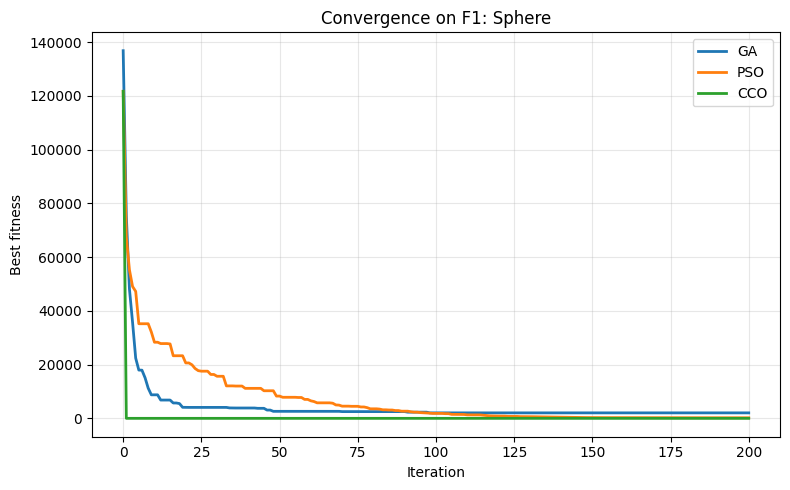

Saved results/benchmark_convergence_F1.png


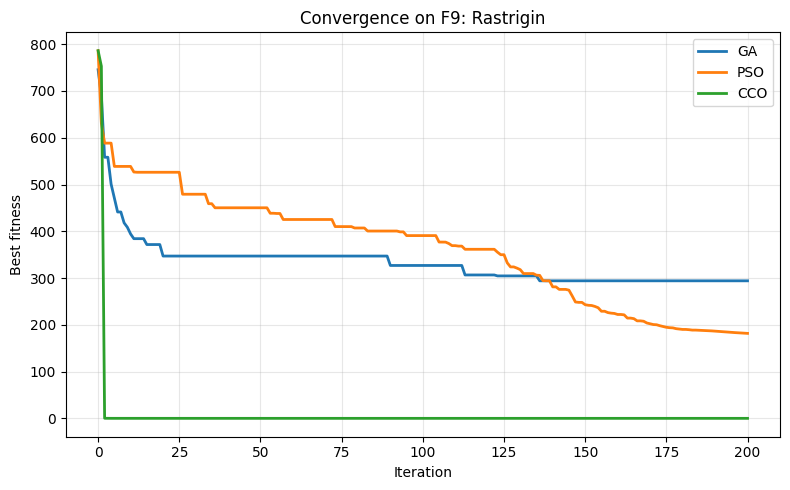

Saved results/benchmark_convergence_F9.png


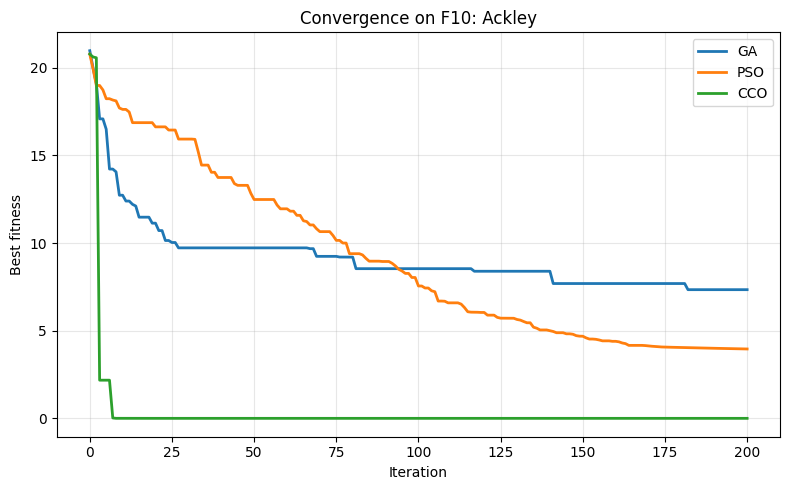

Saved results/benchmark_convergence_F10.png


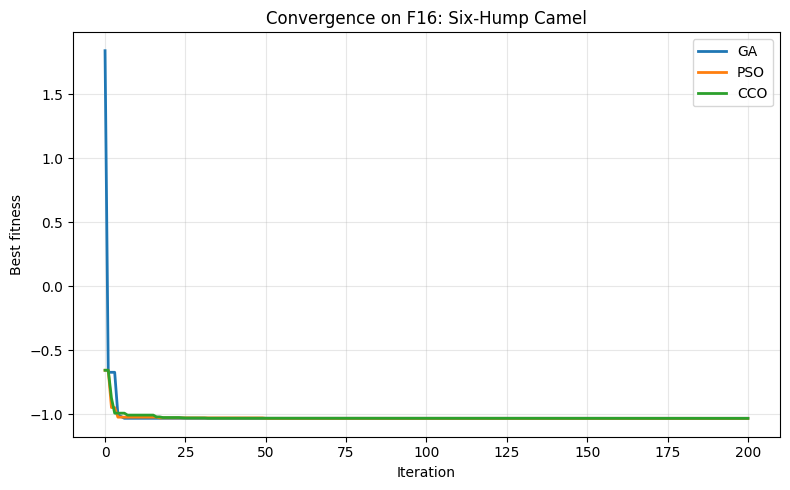

Saved results/benchmark_convergence_F16.png


In [13]:
def plot_benchmark_convergence(benchmark_curves_df, selected_functions=(1, 9, 10, 16)):
    if benchmark_curves_df.empty:
        print("No benchmark curves available.")
        return

    for f_idx in selected_functions:
        sub = benchmark_curves_df[(benchmark_curves_df["Function"] == f_idx) & (benchmark_curves_df["Run"] == 1)]
        if sub.empty:
            continue
        plt.figure(figsize=(8, 5))
        for algo in ["GA", "PSO", "CCO"]:
            s = sub[sub["Algorithm"] == algo]
            if not s.empty:
                plt.plot(s["Iteration"], s["BestFitness"], label=algo, linewidth=2)
        plt.title(f"Convergence on F{f_idx}: {BENCHMARK_NAMES[f_idx]}")
        plt.xlabel("Iteration")
        plt.ylabel("Best fitness")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out = RESULTS_DIR / f"benchmark_convergence_F{f_idx}.png"
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {out}")

plot_benchmark_convergence(benchmark_curves_df)

## Cell 14: Renewable energy forecasting preprocessing

The target is monthly net electricity production in GWh. The model uses a 12-month look-back window to forecast the next month.

The split is time ordered:

- Training: 70 percent
- Validation: 15 percent
- Test: 15 percent

The optimizer only sees validation RMSE. The test set is used only after the best configuration is selected.

In [14]:
SEQ_LEN = 12
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15


def parse_mes_time(value):
    year_part, month_part = str(value).split("-")
    year = 2000 + int(year_part)
    return pd.to_datetime(f"{year}-{month_part}-01", format="%Y-%b-%d")


def create_sequences(values, seq_len):
    X, y = [], []
    for i in range(len(values) - seq_len):
        X.append(values[i:i + seq_len])
        y.append(values[i + seq_len])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


def prepare_energy_task(country, product, seq_len=SEQ_LEN):
    df = df_raw[
        df_raw["Country"].eq(country) &
        df_raw["Product"].eq(product) &
        df_raw["Balance"].eq("Net Electricity Production")
    ].copy()

    if df.empty:
        raise ValueError(f"No records found for {country} - {product}.")

    df["Date"] = df["Time"].apply(parse_mes_time)
    df = df.groupby("Date", as_index=False)["Value"].sum().sort_values("Date")
    df = df.dropna(subset=["Value"])

    values_raw = df["Value"].to_numpy(dtype=np.float32).reshape(-1, 1)
    dates = df["Date"].to_numpy()

    n_seq = len(values_raw) - seq_len
    if n_seq < 30:
        raise ValueError(f"Not enough observations for {country} - {product}. Found {len(values_raw)} rows.")

    train_end = int(n_seq * TRAIN_RATIO)
    val_end = int(n_seq * (TRAIN_RATIO + VAL_RATIO))

    scaler = MinMaxScaler()
    scaler.fit(values_raw[:seq_len + train_end])
    values_scaled = scaler.transform(values_raw).astype(np.float32).flatten()

    X, y = create_sequences(values_scaled, seq_len)
    target_dates = dates[seq_len:]

    bundle = {
        "country": country,
        "product": product,
        "label": f"{country} {product}",
        "df_series": df,
        "scaler": scaler,
        "X_train": X[:train_end],
        "y_train": y[:train_end],
        "X_val": X[train_end:val_end],
        "y_val": y[train_end:val_end],
        "X_test": X[val_end:],
        "y_test": y[val_end:],
        "dates_train": target_dates[:train_end],
        "dates_val": target_dates[train_end:val_end],
        "dates_test": target_dates[val_end:],
    }
    return bundle


def inverse_scale(scaler, values):
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).flatten()

sample_bundle = prepare_energy_task(*CFG["energy_tasks"][0])
print(sample_bundle["label"])
print("Train sequences:", sample_bundle["X_train"].shape)
print("Validation sequences:", sample_bundle["X_val"].shape)
print("Test sequences:", sample_bundle["X_test"].shape)

Germany Wind
Train sequences: (126, 12)
Validation sequences: (27, 12)
Test sequences: (28, 12)


## Cell 15: Plot selected renewable energy time series

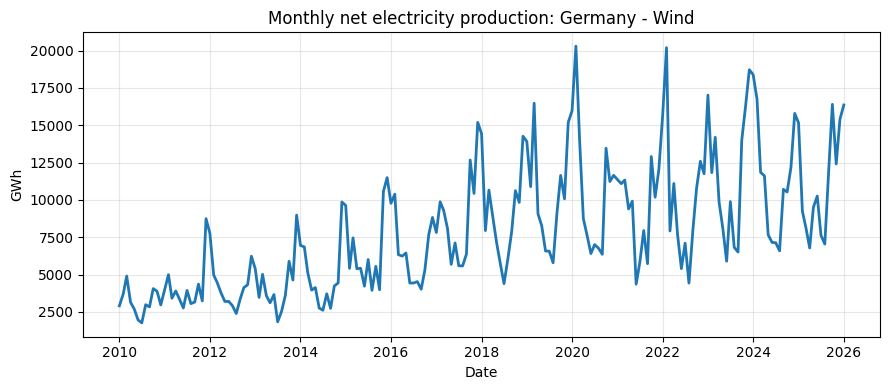

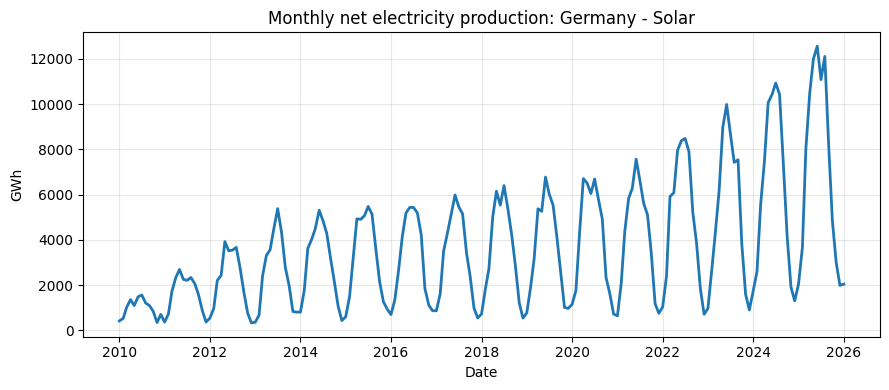

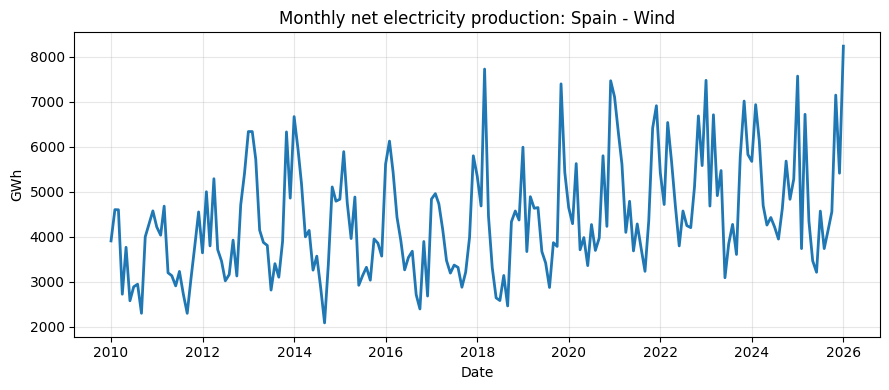

In [15]:
def plot_energy_series(tasks):
    for country, product in tasks:
        bundle = prepare_energy_task(country, product)
        df = bundle["df_series"]
        plt.figure(figsize=(9, 4))
        plt.plot(df["Date"], df["Value"], linewidth=2)
        plt.title(f"Monthly net electricity production: {country} - {product}")
        plt.xlabel("Date")
        plt.ylabel("GWh")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        out = RESULTS_DIR / f"series_{country}_{product}.png".replace(" ", "_")
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()

plot_energy_series(CFG["energy_tasks"][:3])

## Cell 16: LSTM model and hyperparameter decoding

The optimizers search over four decision variables:

1. Hidden units: 16 to 128
2. Dropout rate: 0.0 to 0.5
3. Adam learning rate: 10^-4 to 10^-2, represented in log scale
4. Batch size index: maps to 8, 16, or 32

In [16]:
# Search space:
# 0: hidden units
# 1: dropout
# 2: log10 learning rate
# 3: batch-size index
# 4: log10 weight decay

ENERGY_LOW = np.array([16, 0.00, -5.0, 0.0, -8.0], dtype=float)
ENERGY_HIGH = np.array([160, 0.45, -2.0, 3.0, -3.0], dtype=float)

BATCH_OPTIONS = [8, 16, 32, 64]


def decode_solution(solution):
    sol = np.clip(np.asarray(solution, dtype=float), ENERGY_LOW, ENERGY_HIGH)

    hidden_units = int(np.round(sol[0] / 8) * 8)
    hidden_units = int(np.clip(hidden_units, 16, 160))

    dropout = float(np.clip(sol[1], 0.0, 0.45))

    learning_rate = float(10 ** sol[2])
    learning_rate = float(np.clip(learning_rate, 1e-5, 1e-2))

    batch_idx = int(np.clip(round(sol[3]), 0, len(BATCH_OPTIONS) - 1))
    batch_size = BATCH_OPTIONS[batch_idx]

    weight_decay = float(10 ** sol[4])
    weight_decay = float(np.clip(weight_decay, 1e-8, 1e-3))

    return {
        "hidden_units": hidden_units,
        "dropout": round(dropout, 4),
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "weight_decay": weight_decay,
    }


class LSTMForecaster(nn.Module):
    def __init__(self, hidden_units, dropout):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_units,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.output(out)


def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).unsqueeze(-1).to(DEVICE)


def train_and_evaluate_lstm(
    bundle,
    params,
    epochs=20,
    seed=SEED,
    final=False,
    return_predictions=False
):
    set_global_seed(seed)

    if final:
        # Use train + validation data, but keep an internal validation split for early stopping.
        # This avoids using the test set during training.
        X_pool = np.concatenate([bundle["X_train"], bundle["X_val"]], axis=0)
        y_pool = np.concatenate([bundle["y_train"], bundle["y_val"]], axis=0)

        stop_size = max(6, int(0.15 * len(X_pool)))

        X_train = X_pool[:-stop_size]
        y_train = y_pool[:-stop_size]

        X_stop = X_pool[-stop_size:]
        y_stop = y_pool[-stop_size:]

        X_eval = bundle["X_test"]
        y_eval = bundle["y_test"]
        eval_dates = bundle["dates_test"]

    else:
        X_train = bundle["X_train"]
        y_train = bundle["y_train"]

        X_stop = bundle["X_val"]
        y_stop = bundle["y_val"]

        X_eval = bundle["X_val"]
        y_eval = bundle["y_val"]
        eval_dates = bundle["dates_val"]

    X_train_t = to_tensor(X_train)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(DEVICE)

    X_stop_t = to_tensor(X_stop)
    y_stop_t = torch.tensor(y_stop, dtype=torch.float32).reshape(-1, 1).to(DEVICE)

    X_eval_t = to_tensor(X_eval)

    model = LSTMForecaster(
        hidden_units=params["hidden_units"],
        dropout=params["dropout"]
    ).to(DEVICE)

    optimizer = Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params.get("weight_decay", 0.0)
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(3, epochs // 10),
        min_lr=1e-6
    )

    criterion = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=params["batch_size"],
        shuffle=True
    )

    best_state = None
    best_stop_loss = float("inf")

    patience = max(12, epochs // 3) if not final else max(25, epochs // 4)
    min_delta = 1e-7
    no_improve = 0

    for epoch in range(epochs):
        model.train()

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()

        with torch.no_grad():
            pred_stop = model(X_stop_t)
            stop_loss = criterion(pred_stop, y_stop_t).item()

        scheduler.step(stop_loss)

        if stop_loss < best_stop_loss - min_delta:
            best_stop_loss = stop_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1

            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()

    with torch.no_grad():
        pred_scaled = model(X_eval_t).cpu().numpy().flatten()

    actual = inverse_scale(bundle["scaler"], y_eval)
    predicted = inverse_scale(bundle["scaler"], pred_scaled)

    rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
    mae = float(mean_absolute_error(actual, predicted))
    mape = float(
        np.mean(
            np.abs((actual - predicted) / np.maximum(np.abs(actual), 1e-8))
        ) * 100
    )
    r2 = float(r2_score(actual, predicted))

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "BestStopLoss": float(best_stop_loss),
    }

    if return_predictions:
        return metrics, {
            "dates": eval_dates,
            "actual": actual,
            "predicted": predicted
        }

    return metrics


print("Example decoded solution:", decode_solution([96, 0.2, -3.5, 1, -5]))

Example decoded solution: {'hidden_units': 96, 'dropout': 0.2, 'learning_rate': 0.00031622776601683794, 'batch_size': 16, 'weight_decay': 1e-05}


## Cell 17: Energy objective function with caching

Caching avoids retraining the same configuration repeatedly. This is important because LSTM fitness evaluation is expensive.

In [17]:
FITNESS_CACHE = {}


def make_energy_objective(bundle, epochs, seed):
    label = bundle["label"]

    def objective(solution):
        params = decode_solution(solution)

        key = (
            label,
            seed,
            params["hidden_units"],
            round(params["dropout"], 3),
            round(math.log10(params["learning_rate"]), 4),
            params["batch_size"],
            round(math.log10(params["weight_decay"]), 4),
            epochs,
        )

        if key in FITNESS_CACHE:
            return FITNESS_CACHE[key]

        metrics = train_and_evaluate_lstm(
            bundle,
            params,
            epochs=epochs,
            seed=seed,
            final=False,
            return_predictions=False
        )

        FITNESS_CACHE[key] = metrics["RMSE"]
        return metrics["RMSE"]

    return objective


def seasonal_naive_baseline(bundle):
    actual = inverse_scale(bundle["scaler"], bundle["y_test"])
    predicted = inverse_scale(bundle["scaler"], bundle["X_test"][:, 0])

    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "MAPE": float(
            np.mean(
                np.abs((actual - predicted) / np.maximum(np.abs(actual), 1e-8))
            ) * 100
        ),
        "R2": float(r2_score(actual, predicted)),
    }


def stable_label_seed(label):
    return sum(ord(ch) for ch in label) % 1000


def run_energy_experiments():
    result_rows = []
    convergence_rows = []
    forecast_artifacts = []

    tasks = CFG["energy_tasks"]
    seed_runs = CFG["energy_seed_runs"]
    pop_size = CFG["energy_agents"]
    n_iter = CFG["energy_iter"]
    fitness_epochs = CFG["fitness_epochs"]
    final_epochs = CFG["final_epochs"]

    print(f"Running renewable energy experiments: {len(tasks)} tasks, {seed_runs} seed run(s)")
    print(f"Agents={pop_size}, iterations={n_iter}, fitness epochs={fitness_epochs}, final epochs={final_epochs}")

    for country, product in tasks:
        bundle = prepare_energy_task(country, product)
        baseline = seasonal_naive_baseline(bundle)

        print(
            f"Task: {bundle['label']} | "
            f"Seasonal naive test RMSE={baseline['RMSE']:.3f}"
        )

        for run in range(seed_runs):
            run_seed = SEED + 1000 * run + stable_label_seed(bundle["label"])
            objective = make_energy_objective(
                bundle,
                epochs=fitness_epochs,
                seed=run_seed
            )

            for algo_name, algo_fn in OPTIMIZERS.items():
                print(
                    f"Running {algo_name} on {bundle['label']} | "
                    f"run {run + 1}/{seed_runs}"
                )

                result = algo_fn(
                    objective,
                    ENERGY_LOW,
                    ENERGY_HIGH,
                    pop_size=pop_size,
                    n_iter=n_iter,
                    seed=run_seed + len(algo_name),
                    verbose=False
                )

                params = decode_solution(result.best_position)

                final_metrics, preds = train_and_evaluate_lstm(
                    bundle,
                    params,
                    epochs=final_epochs,
                    seed=run_seed,
                    final=True,
                    return_predictions=True
                )

                row = {
                    "Task": bundle["label"],
                    "Country": country,
                    "Product": product,
                    "Run": run + 1,
                    "Algorithm": algo_name,

                    "ValidationRMSE": result.best_fitness,
                    "TestRMSE": final_metrics["RMSE"],
                    "TestMAE": final_metrics["MAE"],
                    "TestMAPE": final_metrics["MAPE"],
                    "TestR2": final_metrics["R2"],

                    "BaselineRMSE": baseline["RMSE"],
                    "BaselineMAE": baseline["MAE"],
                    "BaselineMAPE": baseline["MAPE"],
                    "BaselineR2": baseline["R2"],

                    "ImprovementVsBaselinePercent": 100
                    * (baseline["RMSE"] - final_metrics["RMSE"])
                    / baseline["RMSE"],

                    "HiddenUnits": params["hidden_units"],
                    "Dropout": params["dropout"],
                    "LearningRate": params["learning_rate"],
                    "BatchSize": params["batch_size"],
                    "WeightDecay": params["weight_decay"],

                    "RuntimeSeconds": result.runtime_seconds,
                }

                result_rows.append(row)
                forecast_artifacts.append({**row, **preds})

                for it, val in enumerate(result.history):
                    convergence_rows.append({
                        "Task": bundle["label"],
                        "Run": run + 1,
                        "Algorithm": algo_name,
                        "Iteration": it,
                        "ValidationRMSE": val,
                    })

    energy_df = pd.DataFrame(result_rows)
    energy_curves_df = pd.DataFrame(convergence_rows)

    energy_df.to_csv(RESULTS_DIR / "energy_results.csv", index=False)
    energy_curves_df.to_csv(RESULTS_DIR / "energy_convergence.csv", index=False)

    return energy_df, energy_curves_df, forecast_artifacts


if RUN_RENEWABLE_EXPERIMENTS:
    energy_df, energy_curves_df, forecast_artifacts = run_energy_experiments()
    display(energy_df)
else:
    energy_df = pd.DataFrame()
    energy_curves_df = pd.DataFrame()
    forecast_artifacts = []
    print("Renewable energy experiments skipped.")

Running renewable energy experiments: 6 tasks, 3 seed run(s)
Agents=12, iterations=15, fitness epochs=30, final epochs=180
Task: Germany Wind | Seasonal naive test RMSE=3414.793
Running GA on Germany Wind | run 1/3
Running PSO on Germany Wind | run 1/3
Running CCO on Germany Wind | run 1/3
Running GA on Germany Wind | run 2/3
Running PSO on Germany Wind | run 2/3
Running CCO on Germany Wind | run 2/3
Running GA on Germany Wind | run 3/3
Running PSO on Germany Wind | run 3/3
Running CCO on Germany Wind | run 3/3
Task: Germany Solar | Seasonal naive test RMSE=1336.833
Running GA on Germany Solar | run 1/3
Running PSO on Germany Solar | run 1/3
Running CCO on Germany Solar | run 1/3
Running GA on Germany Solar | run 2/3
Running PSO on Germany Solar | run 2/3
Running CCO on Germany Solar | run 2/3
Running GA on Germany Solar | run 3/3
Running PSO on Germany Solar | run 3/3
Running CCO on Germany Solar | run 3/3
Task: Spain Wind | Seasonal naive test RMSE=1236.719
Running GA on Spain Wind |

,Task,Country,Product,Run,Algorithm,ValidationRMSE,TestRMSE,TestMAE,TestMAPE,TestR2,...,BaselineMAE,BaselineMAPE,BaselineR2,ImprovementVsBaselinePercent,HiddenUnits,Dropout,LearningRate,BatchSize,WeightDecay,RuntimeSeconds
0,Germany Wind,Germany,Wind,1,GA,2577.259494,2506.984045,2015.510376,17.796785,0.566799,...,2775.857178,24.428139,0.196261,26.584606,112,0.3277,0.002237,16,2.218698e-07,197.225781
1,Germany Wind,Germany,Wind,1,PSO,2567.892813,2399.974375,1972.341431,17.725756,0.602992,...,2775.857178,24.428139,0.196261,29.718314,88,0.3329,0.000960,8,3.664441e-06,262.768384
2,Germany Wind,Germany,Wind,1,CCO,2538.959629,2481.224597,2042.420288,18.333635,0.575656,...,2775.857178,24.428139,0.196261,27.338954,136,0.3025,0.001159,16,7.408866e-06,204.885976
3,Germany Wind,Germany,Wind,2,GA,2545.890119,2443.046459,2005.203735,17.719103,0.588614,...,2775.857178,24.428139,0.196261,28.456976,80,0.2326,0.002360,16,1.922593e-06,184.393131
4,Germany Wind,Germany,Wind,2,PSO,2543.183536,2500.412166,2064.982666,18.256433,0.569068,...,2775.857178,24.428139,0.196261,26.777059,112,0.2364,0.001134,16,4.443476e-06,248.661710
5,Germany Wind,Germany,Wind,2,CCO,2544.048840,2440.263305,2010.371094,18.394072,0.589551,...,2775.857178,24.428139,0.196261,28.538479,112,0.4265,0.001613,8,2.109577e-07,258.924085
6,Germany Wind,Germany,Wind,3,GA,2526.736235,2436.596294,1968.638916,17.300406,0.590784,...,2775.857178,24.428139,0.196261,28.645865,104,0.2518,0.001132,8,4.705920e-07,283.933749
7,Germany Wind,Germany,Wind,3,PSO,2531.060746,2422.450619,1977.329468,17.627390,0.595521,...,2775.857178,24.428139,0.196261,29.060112,104,0.1432,0.001303,16,1.762207e-08,246.095666
8,Germany Wind,Germany,Wind,3,CCO,2521.708845,2455.264548,1977.467896,17.474686,0.584489,...,2775.857178,24.428139,0.196261,28.099177,104,0.2644,0.001135,8,2.218324e-06,228.046960
9,Germany Solar,Germany,Solar,1,GA,626.458174,1396.481785,1177.733765,26.255066,0.875574,...,998.817017,17.638866,0.885976,-4.461932,64,0.2621,0.002830,8,3.663634e-07,240.678807


## Cell 18: Run renewable energy optimization experiments

For each renewable energy forecasting task, GA, PSO, and CCO optimize the same LSTM hyperparameter space. The best configuration is selected using validation RMSE, then retrained and evaluated on the test set.

In [18]:
def run_energy_experiments():
    result_rows = []
    convergence_rows = []
    forecast_artifacts = []

    tasks = CFG["energy_tasks"]
    seed_runs = CFG["energy_seed_runs"]
    pop_size = CFG["energy_agents"]
    n_iter = CFG["energy_iter"]
    fitness_epochs = CFG["fitness_epochs"]
    final_epochs = CFG["final_epochs"]

    print(f"Running renewable energy experiments: {len(tasks)} tasks, {seed_runs} seed run(s)")
    print(f"Agents={pop_size}, iterations={n_iter}, fitness epochs={fitness_epochs}, final epochs={final_epochs}")

    for country, product in tasks:
        bundle = prepare_energy_task(country, product)
        baseline = seasonal_naive_baseline(bundle)
        print(f"Task: {bundle['label']} | Seasonal naive test RMSE={baseline['RMSE']:.3f}")

        for run in range(seed_runs):
            run_seed = SEED + 1000 * run + abs(hash(bundle["label"])) % 1000
            objective = make_energy_objective(bundle, epochs=fitness_epochs, seed=run_seed)

            for algo_name, algo_fn in OPTIMIZERS.items():
                print(f"Running {algo_name} on {bundle['label']} | run {run + 1}/{seed_runs}")
                result = algo_fn(objective, ENERGY_LOW, ENERGY_HIGH, pop_size=pop_size, n_iter=n_iter, seed=run_seed + len(algo_name), verbose=False)
                params = decode_solution(result.best_position)
                final_metrics, preds = train_and_evaluate_lstm(
                    bundle, params, epochs=final_epochs, seed=run_seed, final=True, return_predictions=True
                )

                row = {
                    "Task": bundle["label"],
                    "Country": country,
                    "Product": product,
                    "Run": run + 1,
                    "Algorithm": algo_name,
                    "ValidationRMSE": result.best_fitness,
                    "TestRMSE": final_metrics["RMSE"],
                    "TestMAE": final_metrics["MAE"],
                    "TestMAPE": final_metrics["MAPE"],
                    "BaselineRMSE": baseline["RMSE"],
                    "ImprovementVsBaselinePercent": 100 * (baseline["RMSE"] - final_metrics["RMSE"]) / baseline["RMSE"],
                    "HiddenUnits": params["hidden_units"],
                    "Dropout": params["dropout"],
                    "LearningRate": params["learning_rate"],
                    "BatchSize": params["batch_size"],
                    "RuntimeSeconds": result.runtime_seconds,
                }
                result_rows.append(row)
                forecast_artifacts.append({**row, **preds})

                for it, val in enumerate(result.history):
                    convergence_rows.append({
                        "Task": bundle["label"],
                        "Run": run + 1,
                        "Algorithm": algo_name,
                        "Iteration": it,
                        "ValidationRMSE": val,
                    })

    energy_df = pd.DataFrame(result_rows)
    energy_curves_df = pd.DataFrame(convergence_rows)
    energy_df.to_csv(RESULTS_DIR / "energy_results.csv", index=False)
    energy_curves_df.to_csv(RESULTS_DIR / "energy_convergence.csv", index=False)
    return energy_df, energy_curves_df, forecast_artifacts

if RUN_RENEWABLE_EXPERIMENTS:
    energy_df, energy_curves_df, forecast_artifacts = run_energy_experiments()
    display(energy_df)
else:
    energy_df = pd.DataFrame()
    energy_curves_df = pd.DataFrame()
    forecast_artifacts = []
    print("Renewable energy experiments skipped.")

Running renewable energy experiments: 6 tasks, 3 seed run(s)
Agents=12, iterations=15, fitness epochs=30, final epochs=180
Task: Germany Wind | Seasonal naive test RMSE=3414.793
Running GA on Germany Wind | run 1/3
Running PSO on Germany Wind | run 1/3
Running CCO on Germany Wind | run 1/3
Running GA on Germany Wind | run 2/3
Running PSO on Germany Wind | run 2/3
Running CCO on Germany Wind | run 2/3
Running GA on Germany Wind | run 3/3
Running PSO on Germany Wind | run 3/3
Running CCO on Germany Wind | run 3/3
Task: Germany Solar | Seasonal naive test RMSE=1336.833
Running GA on Germany Solar | run 1/3
Running PSO on Germany Solar | run 1/3
Running CCO on Germany Solar | run 1/3
Running GA on Germany Solar | run 2/3
Running PSO on Germany Solar | run 2/3
Running CCO on Germany Solar | run 2/3
Running GA on Germany Solar | run 3/3
Running PSO on Germany Solar | run 3/3
Running CCO on Germany Solar | run 3/3
Task: Spain Wind | Seasonal naive test RMSE=1236.719
Running GA on Spain Wind |

,Task,Country,Product,Run,Algorithm,ValidationRMSE,TestRMSE,TestMAE,TestMAPE,BaselineRMSE,ImprovementVsBaselinePercent,HiddenUnits,Dropout,LearningRate,BatchSize,RuntimeSeconds
0,Germany Wind,Germany,Wind,1,GA,2563.716443,2440.104199,2019.292236,18.343271,3414.793405,28.543138,128,0.2507,0.002358,16,247.880723
1,Germany Wind,Germany,Wind,1,PSO,2522.627202,2445.341796,1989.539917,17.501385,3414.793405,28.389759,136,0.0770,0.000950,16,327.269669
2,Germany Wind,Germany,Wind,1,CCO,2547.682280,2540.355881,2101.761475,18.606167,3414.793405,25.607333,144,0.0476,0.000504,8,284.477195
3,Germany Wind,Germany,Wind,2,GA,2558.939820,2495.131960,2079.360107,18.775944,3414.793405,26.931686,152,0.2033,0.002180,32,231.637027
4,Germany Wind,Germany,Wind,2,PSO,2566.377603,2428.998868,1997.581665,17.779398,3414.793405,28.868351,96,0.3376,0.002662,16,259.671736
5,Germany Wind,Germany,Wind,2,CCO,2592.664556,2566.955298,2123.129639,18.625603,3414.793405,24.828387,56,0.4500,0.010000,8,176.896695
6,Germany Wind,Germany,Wind,3,GA,2525.584784,2485.069818,2069.573975,18.495213,3414.793405,27.226350,160,0.3007,0.000924,16,248.683777
7,Germany Wind,Germany,Wind,3,PSO,2526.882763,2493.107900,2076.939453,18.821978,3414.793405,26.990960,120,0.1947,0.001139,16,297.183728
8,Germany Wind,Germany,Wind,3,CCO,2527.291040,2515.032405,2085.255371,18.871693,3414.793405,26.348915,120,0.1347,0.001116,16,193.339553
9,Germany Solar,Germany,Solar,1,GA,588.754326,1222.726922,1063.932373,27.998928,1336.833198,8.535566,88,0.0567,0.002354,16,170.005589


## Cell 19: Renewable energy result summary and statistical tests

In [19]:
def energy_summary_and_tests(energy_df):
    if energy_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    summary = (
        energy_df
        .groupby(["Task", "Algorithm"])
        .agg(
            MeanTestRMSE=("TestRMSE", "mean"),
            StdTestRMSE=("TestRMSE", "std"),
            MeanMAE=("TestMAE", "mean"),
            MeanMAPE=("TestMAPE", "mean"),
            MeanImprovement=("ImprovementVsBaselinePercent", "mean"),
            MeanRuntime=("RuntimeSeconds", "mean"),
        )
        .reset_index()
    )
    display(summary)
    summary.to_csv(RESULTS_DIR / "energy_summary.csv", index=False)

    pivot = summary.pivot(index="Task", columns="Algorithm", values="MeanTestRMSE")
    # Generalized to whichever of GA/PSO/CCO/RandomSearch are actually present, so adding the
    # RandomSearch baseline (Cell 9b) automatically extends this test -- no manual edits needed.
    algos_present = [a for a in ["GA", "PSO", "CCO", "RandomSearch"] if a in pivot.columns]
    if len(algos_present) >= 3 and len(pivot) >= 3:
        friedman = stats.friedmanchisquare(*[pivot[a] for a in algos_present])
        print(f"Energy Friedman statistic ({', '.join(algos_present)}): {friedman.statistic:.6f}")
        print(f"Energy Friedman p-value: {friedman.pvalue:.6g}")
    else:
        print("Not enough paired tasks/algorithms for Friedman test.")

    from itertools import combinations
    pairs = list(combinations(algos_present, 2))
    rows = []
    pvals = []
    for a, b in pairs:
        if a in pivot.columns and b in pivot.columns:
            try:
                test = stats.wilcoxon(pivot[a], pivot[b])
                p = test.pvalue
                stat = test.statistic
            except ValueError:
                p = np.nan
                stat = np.nan
            rows.append({"Pair": f"{a} vs {b}", "WilcoxonStatistic": stat, "PValue": p})
            pvals.append(p if not np.isnan(p) else 1.0)

    if rows:
        adjusted = holm_correction(pvals)
        for row, adj in zip(rows, adjusted):
            row["HolmAdjustedPValue"] = adj
    tests = pd.DataFrame(rows)
    display(tests)
    tests.to_csv(RESULTS_DIR / "energy_statistical_tests.csv", index=False)
    if "RandomSearch" in algos_present:
        rs_rows = [r for r in rows if "RandomSearch" in r["Pair"]]
        sig = [r for r in rs_rows if r["HolmAdjustedPValue"] < 0.05]
        if sig:
            print("RandomSearch is significantly different (Holm-adjusted p<0.05) from:",
                  ", ".join(r["Pair"] for r in sig))
        else:
            print("RandomSearch is NOT significantly distinguishable from GA/PSO/CCO on this task --")
            print("the metaheuristic search is not earning its keep here without further evidence.")
    return summary, tests

energy_summary_df, energy_tests_df = energy_summary_and_tests(energy_df)

,Task,Algorithm,MeanTestRMSE,StdTestRMSE,MeanMAE,MeanMAPE,MeanImprovement,MeanRuntime
0,Denmark Solar,CCO,104.549348,11.293806,83.524872,55.081734,-79.572156,243.453279
1,Denmark Solar,GA,95.256220,42.724131,74.860191,50.881003,-63.610439,214.534707
2,Denmark Solar,PSO,114.861007,15.164149,96.078621,72.903720,-97.283283,267.825058
3,Denmark Wind,CCO,329.458892,5.128764,254.083969,15.986549,10.403772,192.260600
4,Denmark Wind,GA,323.138433,2.380335,252.380732,15.776910,12.122619,146.919167
5,Denmark Wind,PSO,330.536909,8.719617,252.480682,15.688813,10.110606,182.957739
6,Germany Solar,CCO,1323.022422,178.085146,1117.800415,29.282557,1.033096,211.158800
7,Germany Solar,GA,1316.152821,353.455759,1149.470927,30.232094,1.546968,179.645845
8,Germany Solar,PSO,1274.728216,106.032831,1072.640727,31.220879,4.645679,256.415905
9,Germany Wind,CCO,2540.781195,25.964059,2103.382161,18.701154,25.594878,218.237814


Energy Friedman statistic: 0.333333
Energy Friedman p-value: 0.846482


,Pair,WilcoxonStatistic,PValue,HolmAdjustedPValue
0,CCO vs GA,6.0,0.4375,1.0
1,CCO vs PSO,6.0,0.4375,1.0
2,GA vs PSO,6.0,0.4375,1.0


## Cell 19b: Efficiency analysis -- accuracy vs. compute cost (energy task)

`RuntimeSeconds` and `ImprovementVsBaselinePercent` are logged per run in `energy_df` but the
original report's "Efficiency-Aware" title never used them. `ImprovementVsBaselinePercent` is
scale-free (unlike raw RMSE, which isn't comparable across tasks with very different GWh ranges),
so it can be averaged across all 6 tasks to give one accuracy number per algorithm, plotted
against mean runtime. Works with just the CSV on disk -- no need to re-run the experiments.

In [ ]:
# --- Efficiency analysis: accuracy (% improvement vs. baseline) vs. compute cost ---------
if "energy_df" in dir() and not energy_df.empty:
    _edf = energy_df
else:
    _candidates = [RESULTS_DIR / "energy_results.csv", Path("ec_project_outputs/energy_results.csv")]
    _src = next((p for p in _candidates if p.exists()), None)
    if _src is None:
        raise FileNotFoundError(
            "No energy_df in memory and no energy_results.csv found in "
            f"{[str(p) for p in _candidates]}. Run Cell 18 first, or point _src at your CSV."
        )
    _edf = pd.read_csv(_src)
    print(f"Loaded {_src} (energy_df not in memory)")

eff = _edf.groupby("Algorithm").agg(
    MeanImprovementPercent=("ImprovementVsBaselinePercent", "mean"),
    StdImprovementPercent=("ImprovementVsBaselinePercent", "std"),
    MeanRuntimeSeconds=("RuntimeSeconds", "mean"),
    StdRuntimeSeconds=("RuntimeSeconds", "std"),
).reset_index()
eff["MeanRuntimeMin"] = eff["MeanRuntimeSeconds"] / 60
fastest_time = eff["MeanRuntimeSeconds"].min()
eff["RuntimeVsFastest_x"] = eff["MeanRuntimeSeconds"] / fastest_time
eff = eff.sort_values("MeanImprovementPercent", ascending=False)

print("=" * 90)
print("EFFICIENCY: mean % improvement vs. seasonal-naive baseline vs. compute cost, per algorithm")
print("(averaged across all tasks/seeds -- improvement % is scale-free, unlike raw RMSE)")
print("=" * 90)
for _, r in eff.iterrows():
    print(f"  {r['Algorithm']:12s} improvement {r['MeanImprovementPercent']:+7.2f}%  "
          f"runtime {r['MeanRuntimeMin']:7.2f} min  ({r['RuntimeVsFastest_x']:.2f}x the fastest)")

# Pareto front: maximize improvement %, minimize runtime (both directions matter).
def _is_dominated(row, others):
    for _, o in others.iterrows():
        if o["Algorithm"] == row["Algorithm"]:
            continue
        not_worse = (o["MeanImprovementPercent"] >= row["MeanImprovementPercent"] and
                      o["MeanRuntimeSeconds"] <= row["MeanRuntimeSeconds"])
        strictly_better = (o["MeanImprovementPercent"] > row["MeanImprovementPercent"] or
                            o["MeanRuntimeSeconds"] < row["MeanRuntimeSeconds"])
        if not_worse and strictly_better:
            return True
    return False

eff["ParetoEfficient"] = ~eff.apply(lambda r: _is_dominated(r, eff), axis=1)
print()
print("Pareto-efficient (nothing else is at least as accurate AND at least as fast):")
print("  " + ", ".join(eff.loc[eff["ParetoEfficient"], "Algorithm"]))
_dominated = eff.loc[~eff["ParetoEfficient"], "Algorithm"].tolist()
if _dominated:
    print("Dominated (worse or equal on BOTH accuracy and speed vs. something else):")
    print("  " + ", ".join(_dominated))

display(eff[["Algorithm", "MeanImprovementPercent", "StdImprovementPercent", "MeanRuntimeMin",
             "RuntimeVsFastest_x", "ParetoEfficient"]])

fig, ax = plt.subplots(figsize=(6, 4.5))
for _, r in eff.iterrows():
    yerr = r["StdImprovementPercent"] if pd.notna(r["StdImprovementPercent"]) else 0
    xerr = r["StdRuntimeSeconds"] / 60 if pd.notna(r["StdRuntimeSeconds"]) else 0
    ax.errorbar(r["MeanRuntimeMin"], r["MeanImprovementPercent"], xerr=xerr, yerr=yerr,
                fmt="o", capsize=3, markersize=8)
    ax.annotate(r["Algorithm"], (r["MeanRuntimeMin"], r["MeanImprovementPercent"]),
                textcoords="offset points", xytext=(8, 4))
ax.set_xlabel("Mean wall-clock runtime per run (minutes) -- lower is better")
ax.set_ylabel("Mean % improvement vs. seasonal-naive baseline -- higher is better")
ax.set_title("Accuracy vs. compute cost (renewable-energy task, all 6 series)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "efficiency_pareto_energy.png", dpi=150)
plt.show()
print(f"\nSaved figure -> {RESULTS_DIR / 'efficiency_pareto_energy.png'}")


## Cell 20: Renewable energy convergence plots

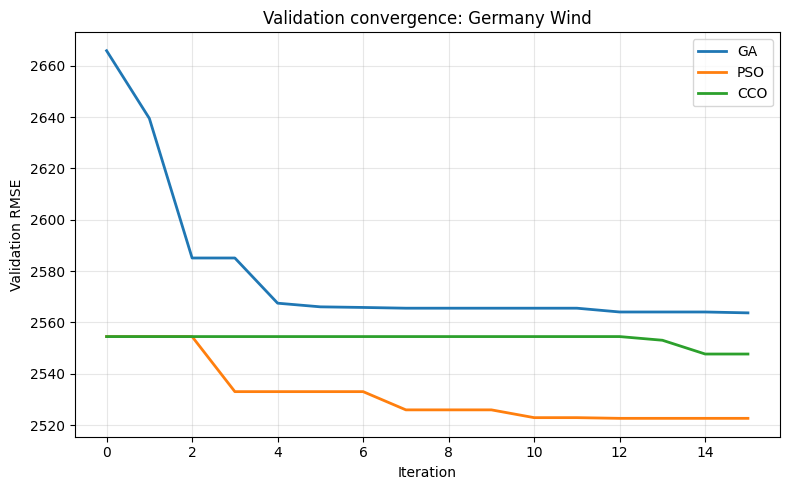

Saved results/energy_convergence_Germany_Wind.png


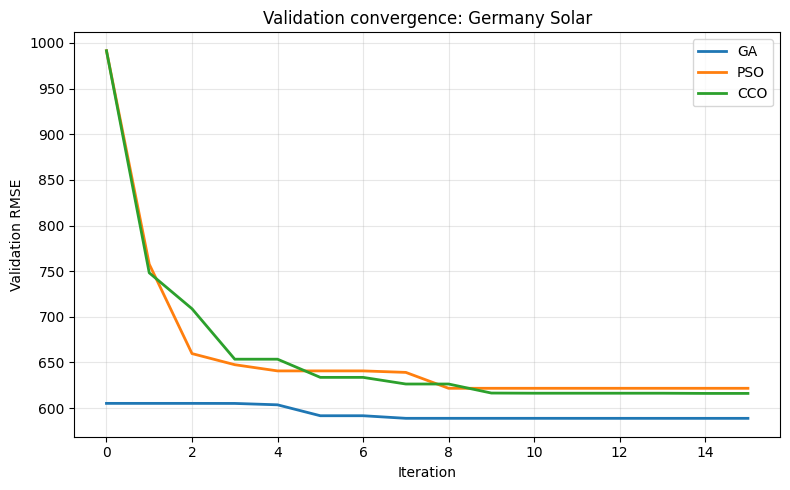

Saved results/energy_convergence_Germany_Solar.png


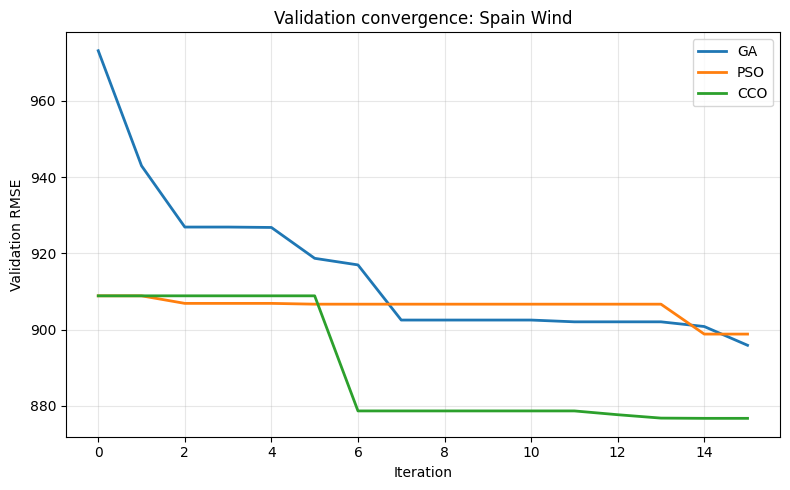

Saved results/energy_convergence_Spain_Wind.png


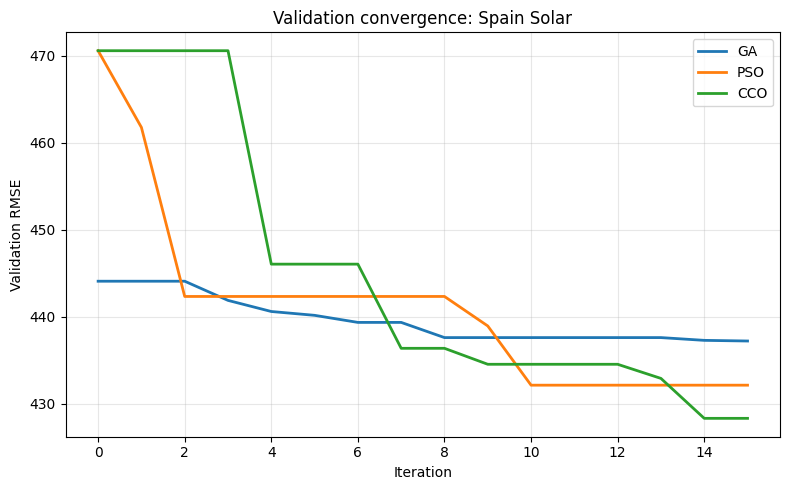

Saved results/energy_convergence_Spain_Solar.png


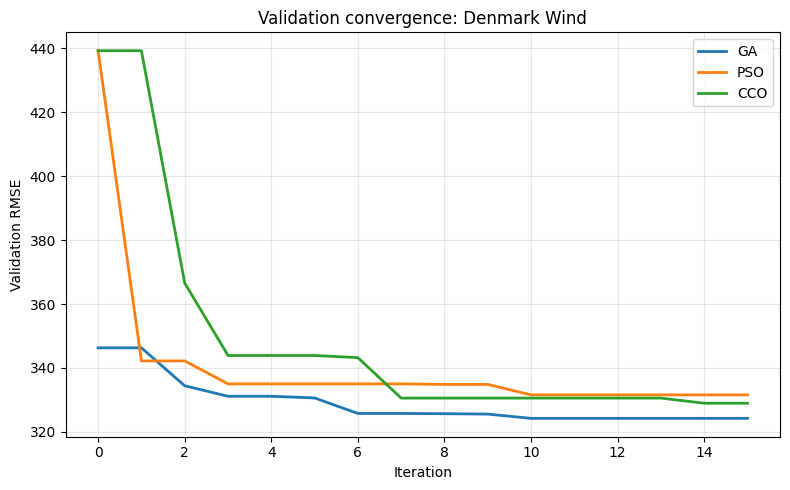

Saved results/energy_convergence_Denmark_Wind.png


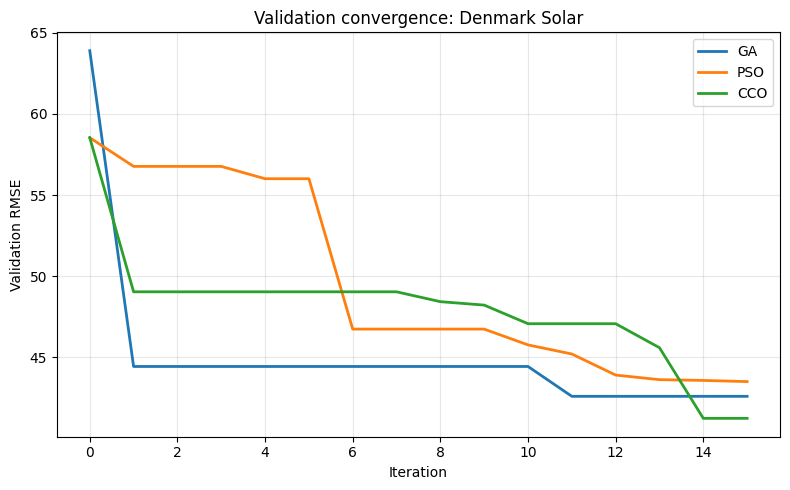

Saved results/energy_convergence_Denmark_Solar.png


In [20]:
def plot_energy_convergence(energy_curves_df):
    if energy_curves_df.empty:
        print("No energy convergence curves available.")
        return

    for task in energy_curves_df["Task"].unique():
        sub = energy_curves_df[(energy_curves_df["Task"] == task) & (energy_curves_df["Run"] == 1)]
        plt.figure(figsize=(8, 5))
        for algo in ["GA", "PSO", "CCO"]:
            s = sub[sub["Algorithm"] == algo]
            if not s.empty:
                plt.plot(s["Iteration"], s["ValidationRMSE"], label=algo, linewidth=2)
        plt.title(f"Validation convergence: {task}")
        plt.xlabel("Iteration")
        plt.ylabel("Validation RMSE")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out = RESULTS_DIR / f"energy_convergence_{task}.png".replace(" ", "_").replace("/", "_")
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {out}")

plot_energy_convergence(energy_curves_df)

## Cell 21: Forecast plots for the best algorithm per task

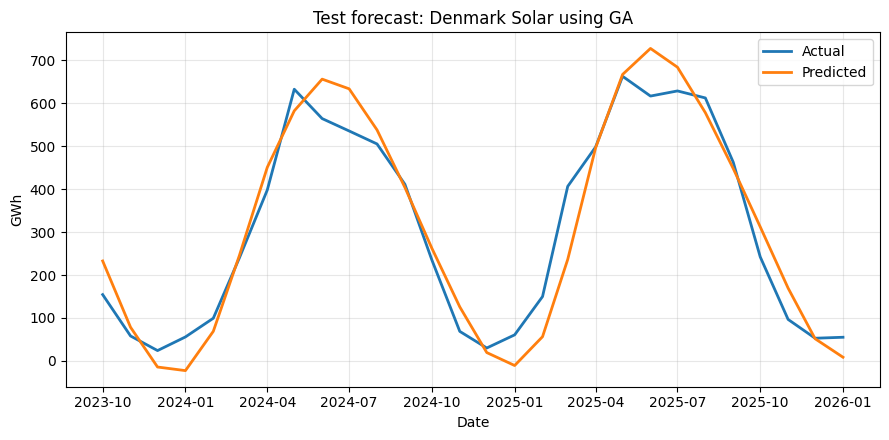

Saved results/forecast_Denmark_Solar_GA.png


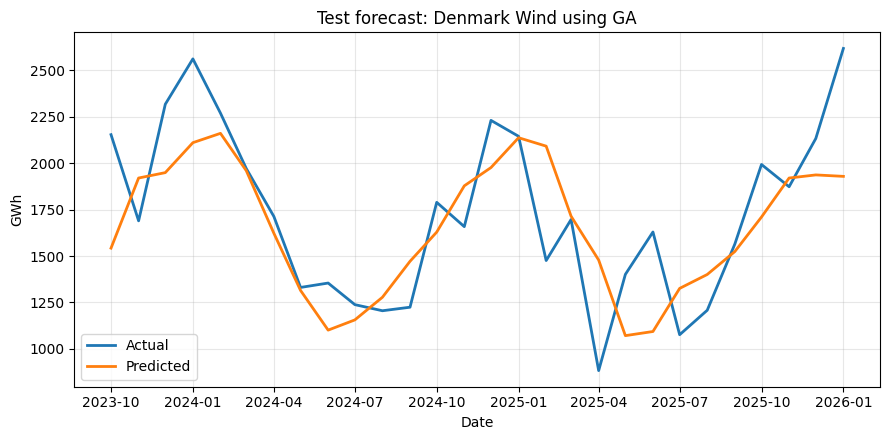

Saved results/forecast_Denmark_Wind_GA.png


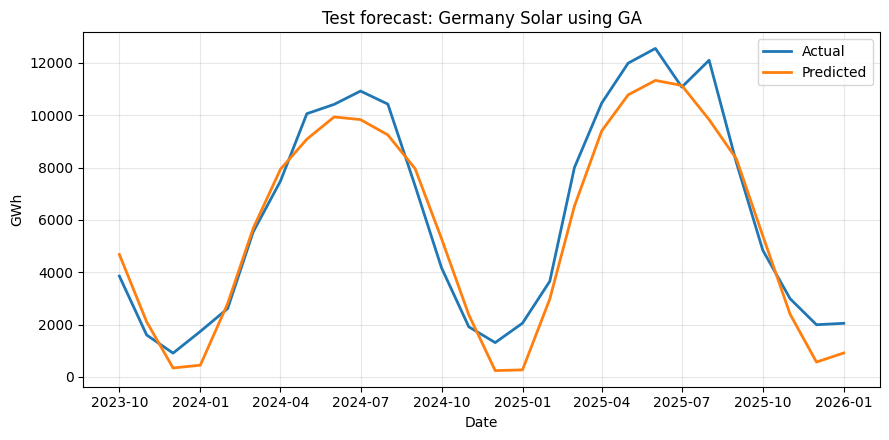

Saved results/forecast_Germany_Solar_GA.png


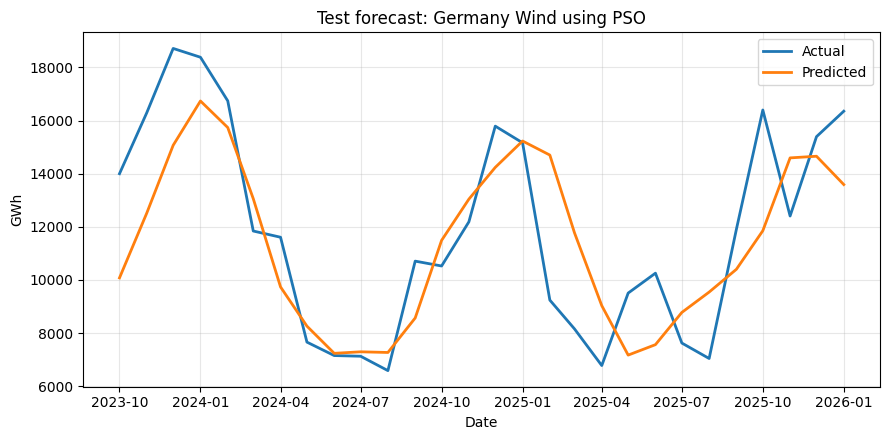

Saved results/forecast_Germany_Wind_PSO.png


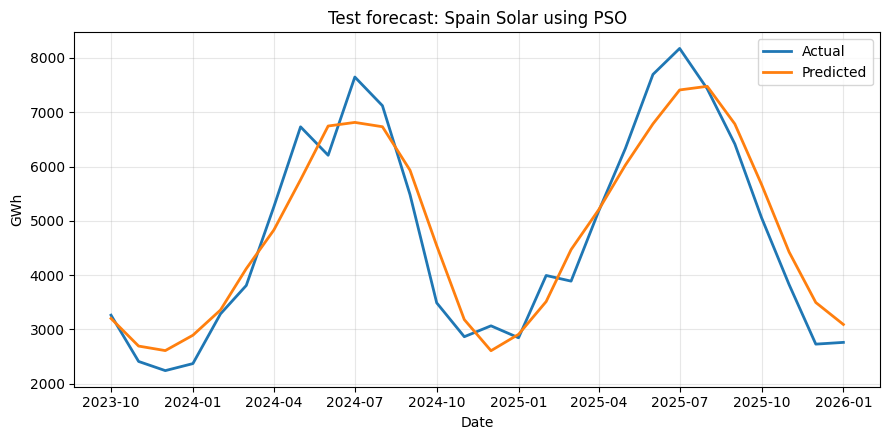

Saved results/forecast_Spain_Solar_PSO.png


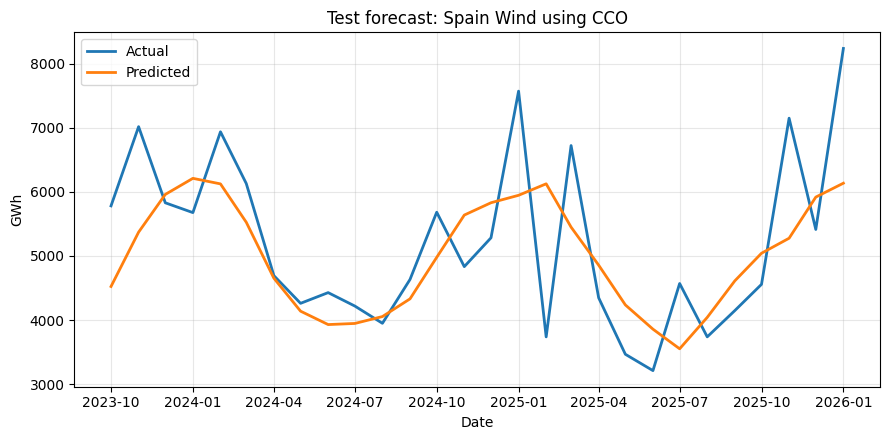

Saved results/forecast_Spain_Wind_CCO.png


In [21]:
def plot_best_forecasts(energy_df, forecast_artifacts):
    if energy_df.empty or not forecast_artifacts:
        print("No forecast artifacts available.")
        return

    best_rows = energy_df.loc[energy_df.groupby("Task")["TestRMSE"].idxmin()]
    for _, best in best_rows.iterrows():
        matches = [a for a in forecast_artifacts if a["Task"] == best["Task"] and a["Algorithm"] == best["Algorithm"] and a["Run"] == best["Run"]]
        if not matches:
            continue
        artifact = matches[0]
        plt.figure(figsize=(9, 4.5))
        plt.plot(artifact["dates"], artifact["actual"], label="Actual", linewidth=2)
        plt.plot(artifact["dates"], artifact["predicted"], label="Predicted", linewidth=2)
        plt.title(f"Test forecast: {artifact['Task']} using {artifact['Algorithm']}")
        plt.xlabel("Date")
        plt.ylabel("GWh")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        out = RESULTS_DIR / f"forecast_{artifact['Task']}_{artifact['Algorithm']}.png".replace(" ", "_").replace("/", "_")
        plt.savefig(out, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved {out}")

plot_best_forecasts(energy_df, forecast_artifacts)

## Cell 22: RMSE heatmap without external styling dependencies

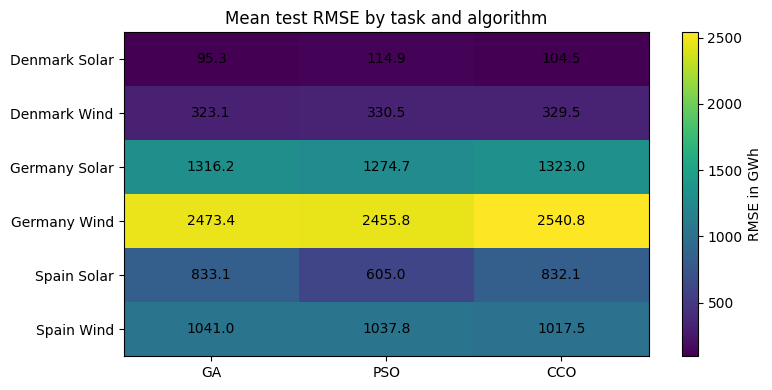

Saved results/energy_rmse_heatmap.png


In [22]:
def plot_energy_rmse_heatmap(energy_summary_df):
    if energy_summary_df.empty:
        print("No energy summary available.")
        return
    pivot = energy_summary_df.pivot(index="Task", columns="Algorithm", values="MeanTestRMSE")
    algos = [a for a in ["GA", "PSO", "CCO"] if a in pivot.columns]
    pivot = pivot[algos]

    fig, ax = plt.subplots(figsize=(8, max(4, 0.6 * len(pivot))))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Mean test RMSE by task and algorithm")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("RMSE in GWh")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha="center", va="center")

    plt.tight_layout()
    out = RESULTS_DIR / "energy_rmse_heatmap.png"
    plt.savefig(out, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

plot_energy_rmse_heatmap(energy_summary_df)

## Cell 23: Export all project outputs

This creates a zip file containing all generated CSV tables and plots.

In [23]:
zip_path = shutil.make_archive("ec_project_outputs", "zip", RESULTS_DIR)
print(f"Exported: {zip_path}")
print("Files in results folder:")
for p in sorted(RESULTS_DIR.iterdir()):
    print("-", p.name)

Exported: /content/ec_project_outputs.zip
Files in results folder:
- benchmark_average_ranks.csv
- benchmark_convergence.csv
- benchmark_convergence_F1.png
- benchmark_convergence_F10.png
- benchmark_convergence_F16.png
- benchmark_convergence_F9.png
- benchmark_results.csv
- benchmark_statistical_tests.csv
- benchmark_summary.csv
- energy_convergence.csv
- energy_convergence_Denmark_Solar.png
- energy_convergence_Denmark_Wind.png
- energy_convergence_Germany_Solar.png
- energy_convergence_Germany_Wind.png
- energy_convergence_Spain_Solar.png
- energy_convergence_Spain_Wind.png
- energy_results.csv
- energy_rmse_heatmap.png
- energy_statistical_tests.csv
- energy_summary.csv
- forecast_Denmark_Solar_GA.png
- forecast_Denmark_Wind_GA.png
- forecast_Germany_Solar_GA.png
- forecast_Germany_Wind_PSO.png
- forecast_Spain_Solar_PSO.png
- forecast_Spain_Wind_CCO.png
- series_Germany_Solar.png
- series_Germany_Wind.png
- series_Spain_Wind.png


In [25]:
from google.colab import files
files.download("/content/ec_project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation guide for the report

Use these points in the Experimental Results and Discussion sections:

1. The benchmark functions evaluate whether each optimizer can handle unimodal, multimodal, and fixed-dimensional landscapes.
2. The renewable energy experiment evaluates whether the optimizer can tune a practical forecasting model, not only synthetic functions.
3. Validation RMSE is used as the fitness value because it estimates generalization performance during optimization.
4. Test RMSE is reported only after optimization to avoid optimistic bias.
5. If CCO obtains lower average rank or lower RMSE than GA and PSO, this supports its usefulness for the selected green energy optimization problem.
6. If the statistical tests are not significant, describe the result honestly as promising but not conclusive, especially if the number of independent runs is small.
7. The novelty of the project is applying the recent CCO optimizer to LSTM hyperparameter optimization for renewable electricity forecasting.

Recommended title:

Efficiency-Aware Metaheuristic Optimization for Renewable Energy Forecasting: A Comparative Study of GA, PSO, and Cuckoo Catfish Optimizer